In [10]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding
from torch.utils.data import DataLoader
from chop import MaseGraph
from chop.tools import get_tokenized_dataset

In [11]:
import math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from chop import MaseGraph
from transformers import DataCollatorWithPadding, AutoTokenizer
from datasets import load_dataset

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    props = torch.cuda.get_device_properties(0)
    print("Using CUDA device:", props.name)
else:
    DEVICE = torch.device("cpu")
    print("CUDA not available — using CPU")


MODEL_CKPT = "/vol/bitbucket/ug22/adls-data/models/bert-base-glue-mnli-baseline"
TOKENIZER_CKPT = "bert-base-uncased"
NUM_LABELS = 3
# === Data ===

raw = load_dataset("glue", "mnli")
raw = raw.filter(lambda x: x["label"] >= 0)
raw["test"] = raw["validation_matched"]

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_CKPT)
dataset = raw.map(
    lambda x: tokenizer(x["premise"], x["hypothesis"], truncation=True, padding="max_length", max_length=128),
    batched=True,
)

from transformers import default_data_collator

collator = default_data_collator

def make_loader(split):
    cols_to_remove = [c for c in dataset[split].column_names if c not in ["input_ids", "attention_mask", "label"]]
    ds = dataset[split].remove_columns(cols_to_remove).rename_column("label", "labels")
    return ds

train_loader = make_loader("train")
train_dataloader = DataLoader(train_loader, batch_size=32, shuffle=True, collate_fn=collator)

eval_loader = make_loader("test").train_test_split(test_size=0.5, seed=42)# Use only a subset of the eval set for faster experimentation
val_dataloader = DataLoader(eval_loader["train"], batch_size=64, collate_fn=collator)
test_dataloader = DataLoader(eval_loader["test"], batch_size=64, collate_fn=collator)


Using CUDA device: NVIDIA GeForce RTX 4080


In [12]:
# eval_ds = dataset["test"].remove_columns(["text", "token_type_ids"]).rename_column("label", "labels")
# train_ds = dataset["train"].remove_columns(["text", "token_type_ids"]).rename_column("label", "labels")
# # Split eval_ds into validation and test sets (e.g. 50/50 split)
# split_ds = eval_ds.train_test_split(test_size=0.5, seed=42)

# val_ds = split_ds["train"]
# test_ds = split_ds["test"]

# print(val_ds)
# print(test_ds)

# print(f"val_ds size: {len(val_ds)}")
# print(f"test_ds size: {len(test_ds)}")


# train_dataloader = DataLoader(
#     train_ds,
#     batch_size=64,
#     shuffle=True,
#     collate_fn=DataCollatorWithPadding(tokenizer),
# )

# test_dataloader = DataLoader(
#     test_ds,
#     batch_size=64,
#     shuffle=False,
#     collate_fn=DataCollatorWithPadding(tokenizer),
# )

# val_dataloader = DataLoader(
#     val_ds,
#     batch_size=64,
#     shuffle=False,
#     collate_fn=DataCollatorWithPadding(tokenizer),
# )


In [18]:

@torch.no_grad()
def eval_accuracy(model, dataloader, device="cuda"):
    model.eval()
    correct, total = 0, 0
    for batch in tqdm(dataloader, desc="Eval Accuracy"):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        logits = out["logits"] if isinstance(out, dict) else out.logits
        correct += (logits.argmax(dim=-1) == batch["labels"]).sum().item()
        total += batch["labels"].size(0)
    acc = correct / total
    print(f"Accuracy: {acc * 100:.2f}% ({correct}/{total})")
    return acc

@torch.no_grad()
def eval_accuracy_head(model, dataloader, device="cuda", head_idx=0):
    model.eval()
    correct, total = 0, 0
    for batch in tqdm(dataloader, desc=f"Eval Accuracy Head {head_idx}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model.forward_no_exit_criteria(**batch, head_idx=head_idx)
        logits = out["logits"] if isinstance(out, dict) else out.logits
        correct += (logits.argmax(dim=-1) == batch["labels"]).sum().item()
        total += batch["labels"].size(0)
    acc = correct / total
    print(f"Head {head_idx} Accuracy: {acc * 100:.2f}% ({correct}/{total})")
    return acc

@torch.no_grad()
def eval_speed(model, dataloader, device="cuda", num_batches=100, warmup=10):
    model.eval()
    batches = list(dataloader)[:warmup + num_batches]
    # warmup
    for b in batches[:warmup]:
        model(**{k: v.to(device) for k, v in b.items()})
    if device == "cuda":
        torch.cuda.synchronize()

    # timed
    times, samples = [], 0
    for b in batches[warmup:]:
        if device == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        model(**{k: v.to(device) for k, v in b.items()})
        if device == "cuda":
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
        samples += b["input_ids"].size(0)
    avg_per_batch_ms = np.mean(times) * 1000
    avg_per_sample_ms = (sum(times) / samples) * 1000
    total = sum(times)
    print(f"{samples} samples in {total:.4f}s")
    print(f"Throughput:      {samples / total:.1f} samples/sec")
    print(f"Avg batch:       {np.mean(times) * 1000:.2f} ms")
    print(f"Avg per-sample:  {total / samples * 1000:.2f} ms")
    return [avg_per_batch_ms, avg_per_sample_ms]


In [31]:
import copy
class EarlyExitBert(nn.Module):
    def __init__(self, original_model, threshold=0.9):
        super().__init__()
        # Extracted submodules 
        self.bert = original_model.bert
        print(self.bert)
        
        # In a generic module graph, children might not be inside a ModuleList with length
        self.encoder_layers = nn.ModuleList(list(self.bert.encoder.layer.children()))
        self.num_layers = len(self.encoder_layers)
        
        # Construct all classifier heads
        self.classifier_heads = nn.ModuleList([copy.deepcopy(original_model.classifier) for _ in range(self.num_layers)])
        self.classifier_thresholds = [threshold for _ in range(self.num_layers)]
    def forward(self, input_ids, attention_mask, labels=None, return_exit_index=False):
        device = input_ids.device
        batch_size = input_ids.size(0)

        # Standard representation mask
        extended_attention_mask = self.bert.get_extended_attention_mask(attention_mask, input_ids.size(), device)
        
        # Step 1: Embeddings
        hidden_states = self.bert.embeddings(input_ids=input_ids)
        
        final_logits = torch.zeros(batch_size, self.classifier_heads[-1].out_features, device=device)
        
        # We index elements to dynamically shrink batch sizes across layers
        active_mask = extended_attention_mask
        active_indices = torch.arange(batch_size, device=device)

        for i, layer_module in enumerate(self.encoder_layers):
            
            # Step 2: Layer Forward
            layer_outputs = layer_module(hidden_states, attention_mask=active_mask)
            hidden_states = layer_outputs[0]
            
            # Step 3: Compute confidence through pooling and classification
            # cls_token = hidden_states[:, 0]
            # pooled_output = self.bert.pooler.dense(cls_token)
            # pooled_output = self.bert.pooler.activation(pooled_output)
            pooled_output = self.bert.pooler(hidden_states)
            logits = self.classifier_heads[i](pooled_output)
            
            if i == self.num_layers - 1:
                final_logits[active_indices] = logits
                break

            probs = F.softmax(logits, dim=-1)
            max_probs, _ = torch.max(probs, dim=-1)
            
            # Step 4: Early Exit Criteria
            confident = max_probs >= self.classifier_thresholds[i]
            
            # Store completed outputs
            confident_indices = active_indices[confident]
            final_logits[confident_indices] = logits[confident]
            
            not_confident = ~confident
            if not not_confident.any():
                break
            
            # Dynamically shrink tensor blocks to only compute unconfident targets in next layer
            active_indices = active_indices[not_confident]
            hidden_states = hidden_states[not_confident]
            active_mask = active_mask[not_confident]
        

        return {"logits": final_logits}, active_indices if return_exit_index else None

    def forward_no_exit_criteria(self, input_ids, attention_mask, labels=None, head_idx=-1):
        if head_idx == -1:
            head_idx = self.num_layers - 1
        device = input_ids.device
        batch_size = input_ids.size(0)

        # Standard representation mask
        extended_attention_mask = self.bert.get_extended_attention_mask(attention_mask, input_ids.size(), device)
        
        # Step 1: Embeddings
        hidden_states = self.bert.embeddings(input_ids=input_ids)
        
        final_logits = torch.zeros(batch_size, self.classifier_heads[-1].out_features, device=device)
        
        # We index elements to dynamically shrink batch sizes across layers
        active_mask = extended_attention_mask
        active_indices = torch.arange(batch_size, device=device)

        for i, layer_module in enumerate(self.encoder_layers):
            if i > head_idx:
                break
            
            # Step 2: Layer Forward
            layer_outputs = layer_module(hidden_states, attention_mask=active_mask)
            hidden_states = layer_outputs[0]
            
            # Step 3: Compute confidence through pooling and classification
            # cls_token = hidden_states[:, 0]
            # pooled_output = self.bert.pooler.dense(cls_token)
            # pooled_output = self.bert.pooler.activation(pooled_output)
        
        pooled_output = self.bert.pooler(hidden_states)

        final_logits = self.classifier_heads[head_idx](pooled_output)

        return {"logits": final_logits}


    def finetune_classifier_head(self, head_idx, train_dataloader, device):
        # Freeze all layers except the specified classifier head
        for param in self.bert.parameters():
            param.requires_grad = False
        for i, classifier_head in enumerate(self.classifier_heads):
            if i == head_idx:
                for param in classifier_head.parameters():
                    param.requires_grad = True
            else:
                for param in classifier_head.parameters():
                    param.requires_grad = False
        # Just use loss.backward() and an optimizer step on the specified head
        optimizer = torch.optim.Adam(self.classifier_heads[head_idx].parameters(), lr=1e-4)
        loss_fn = nn.CrossEntropyLoss()
        self.train()
        for batch in tqdm(train_dataloader, desc=f"Finetuning head {head_idx}"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = self.forward_no_exit_criteria(batch["input_ids"], batch["attention_mask"], head_idx=head_idx)
            logits = outputs["logits"]
            loss = loss_fn(logits, batch["labels"])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Based on the final loss, set the threshold for the layer
    def set_threshold(self, threshold, head_idx=None):
        if head_idx is None:
            self.classifier_thresholds = [threshold for _ in range(self.num_layers)]
            return
        self.classifier_thresholds[head_idx] = threshold
        
    @property
    def num_heads(self):
        return self.num_layers



In [15]:
# Baseline
print("=== BASELINE ===")
mg = MaseGraph.from_checkpoint(MODEL_CKPT)
baseline_model = mg.model.to(DEVICE)
baseline_acc = eval_accuracy(baseline_model, test_dataloader)
print("GPU:"); eval_speed(baseline_model, test_dataloader)

=== BASELINE ===


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
Eval Accuracy: 100%|██████████| 77/77 [00:05<00:00, 13.22it/s]


Accuracy: 81.97% (4023/4908)
GPU:
4268 samples in 4.8255s
Throughput:      884.5 samples/sec
Avg batch:       72.02 ms
Avg per-sample:  1.13 ms


[np.float64(72.02253713699947), 1.1306255829847622]

In [16]:
THRESHOLD = 0.75
print("\n" + "="*50)
print(f"EVALUATING BERT BASE (Threshold = {THRESHOLD})")
print("="*50)

hf_model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=NUM_LABELS)
hf_model.load_state_dict(baseline_model.state_dict(), strict=False)
hf_model = hf_model.to(DEVICE)


early_exit_bert = EarlyExitBert(hf_model, threshold=THRESHOLD).to(DEVICE)
early_exit_bert_finetuned = copy.deepcopy(early_exit_bert)


eval_accuracy(early_exit_bert, test_dataloader, device=DEVICE)
eval_speed(early_exit_bert, test_dataloader, device=DEVICE)

# Based on number of labels, we can try different thresholds to see the accuracy/latency tradeoff curve and also for the tool to determine best tradeoff for user needs

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



EVALUATING BERT BASE (Threshold = 0.75)
BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          

Eval Accuracy:   0%|          | 0/77 [00:00<?, ?it/s]/vol/bitbucket/dt822/adls/.venv/lib/python3.11/site-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
Eval Accuracy: 100%|██████████| 77/77 [00:04<00:00, 17.09it/s]


Accuracy: 78.12% (3834/4908)
4268 samples in 4.1746s
Throughput:      1022.4 samples/sec
Avg batch:       62.31 ms
Avg per-sample:  0.98 ms


[np.float64(62.30740013633118), 0.9781152317559019]

In [30]:
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── 1. Reset all thresholds before search ────────────────────────────────────
for head_idx in range(early_exit_bert_finetuned.num_heads):
    early_exit_bert_finetuned.set_threshold(0.5, head_idx=head_idx)

# ── 2. Bayesian optimisation over joint threshold vector ─────────────────────
thresholds      = [0.3, 0.5, 0.65, 0.7, 0.73, 0.75, 0.77, 0.8, 0.9]
latency_budget  = 70   # ms per batch

def objective(trial):
    for head_idx in range(early_exit_bert_finetuned.num_heads):
        t = trial.suggest_categorical(f"threshold_{head_idx}", thresholds)
        early_exit_bert_finetuned.set_threshold(t, head_idx=head_idx)

    latency = eval_speed(early_exit_bert_finetuned, val_dataloader, device=DEVICE)[0]
    if latency > latency_budget:
        return 0.0                          # hard constraint, instead use a penalty function if you want a softer penalty

    return eval_accuracy(early_exit_bert_finetuned, val_dataloader, device=DEVICE)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"\nBest validation accuracy : {study.best_value:.4f}")
print(f"Best thresholds          : {study.best_params}")

# Apply best thresholds
for head_idx in range(early_exit_bert_finetuned.num_heads):
    t = study.best_params[f"threshold_{head_idx}"]
    early_exit_bert_finetuned.set_threshold(t, head_idx=head_idx)

# ── 3. Profile exit rates to find heads worth keeping ────────────────────────
early_exit_bert_finetuned.eval()

exit_counts = [0] * early_exit_bert_finetuned.num_heads
total        = 0

with torch.no_grad():
    for batch in val_dataloader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)
        batch_size     = input_ids.size(0)
        total         += batch_size

        # Run sample-by-sample so we can record which head each exits at.
        # Adjust this block if your model exposes exit indices in batch mode.
        for i in range(batch_size):
            ids  = input_ids[i].unsqueeze(0)
            mask = attention_mask[i].unsqueeze(0)

            _, exit_head = early_exit_bert_finetuned(
                ids, mask, return_exit_index=True   # <-- expose this in your model
            )
            exit_counts[exit_head] += 1

exit_rates = [c / total for c in exit_counts]

print("\nExit-rate profile after optimisation:")
for i, rate in enumerate(exit_rates):
    bar = "█" * int(rate * 40)
    print(f"  Head {i:>2d} | threshold {study.best_params[f'threshold_{i}']:.2f} "
          f"| exit rate {rate:.3f}  {bar}")

# ── 4. Prune heads that contribute nothing ───────────────────────────────────
MIN_EXIT_RATE = 0.01   # heads below 1 % exit rate are considered dead

dead_heads = [i for i, r in enumerate(exit_rates) if r < MIN_EXIT_RATE]
if dead_heads:
    print(f"\nPruning dead heads (exit rate < {MIN_EXIT_RATE}): {dead_heads}")
    # Setting threshold to 1.0 effectively disables the branch — nothing is
    # ever confident enough to exit, so every sample passes straight through.
    for i in dead_heads:
        early_exit_bert_finetuned.set_threshold(1.0, head_idx=i)
else:
    print("\nNo dead heads found — all branches are active.")

# ── 5. Final evaluation on test set ──────────────────────────────────────────
print("\n" + "="*50)
print("Final evaluation on test set")
print("="*50)
eval_accuracy(early_exit_bert_finetuned, test_dataloader, device=DEVICE)
eval_speed(early_exit_bert_finetuned,    test_dataloader, device=DEVICE)

  0%|          | 0/200 [00:00<?, ?it/s]/vol/bitbucket/dt822/adls/.venv/lib/python3.11/site-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


4267 samples in 3.8258s
Throughput:      1115.3 samples/sec
Avg batch:       57.10 ms
Avg per-sample:  0.90 ms


Best trial: 0. Best value: 0.766456:   0%|          | 1/200 [00:09<30:57,  9.33s/it]

Accuracy: 76.65% (3761/4907)
4267 samples in 3.2035s
Throughput:      1332.0 samples/sec
Avg batch:       47.81 ms
Avg per-sample:  0.75 ms


Best trial: 0. Best value: 0.766456:   1%|          | 2/200 [00:17<28:24,  8.61s/it]

...

Best trial: 150. Best value: 0.804361: 100%|█████████▉| 199/200 [28:55<00:08,  8.94s/it]

Accuracy: 73.85% (3624/4907)
4267 samples in 4.5993s
Throughput:      927.8 samples/sec
Avg batch:       68.65 ms
Avg per-sample:  1.08 ms


Best trial: 150. Best value: 0.804361: 100%|██████████| 200/200 [29:06<00:00,  8.73s/it]


Accuracy: 79.05% (3879/4907)

Best validation accuracy : 0.8044
Best thresholds          : {'threshold_0': 0.65, 'threshold_1': 0.65, 'threshold_2': 0.8, 'threshold_3': 0.75, 'threshold_4': 0.77, 'threshold_5': 0.9, 'threshold_6': 0.9, 'threshold_7': 0.9, 'threshold_8': 0.8, 'threshold_9': 0.9, 'threshold_10': 0.77, 'threshold_11': 0.7}


TypeError: EarlyExitBert.forward() got an unexpected keyword argument 'return_exit_index'

In [29]:
# Finetuning experiment here
import matplotlib.pyplot as plt

# Finetune each head on the training data, then evaluate accuracy and speed again to see if we can recover some of the lost accuracy from early exiting. We can also compare how much each head contributes to the final accuracy and speed tradeoff.

# for head_idx in range(early_exit_bert_finetuned.num_heads):
#     print("\n" + "="*50)
#     print(f"Finetuning head {head_idx}...")
#     print("="*50)
#     early_exit_bert_finetuned.finetune_classifier_head(head_idx, train_dataloader, device=DEVICE)

# # Save early_exit_bert_finetuned model state dict for later use
# torch.save(early_exit_bert_finetuned.state_dict(), "early_exit_bert_finetuned.pth")
for head_idx in range(early_exit_bert_finetuned.num_heads):
    early_exit_bert_finetuned.set_threshold(0.5, head_idx=head_idx) # Set all thresholds to 0.5 before finetuning

# Use the validation set to select the best threshold after finetuning, for each head
thresholds = [0.3, 0.5, 0.65, 0.7, 0.73, 0.75, 0.77, 0.8, 0.9]

latency_constraint = 70 # ms per batch
for head_idx in range(early_exit_bert_finetuned.num_heads):
    print("\n" + "="*50)
    print(f"Selecting threshold for head {head_idx}...")
    print("="*50)
    best_acc = 0
    best_threshold = 0.5
    for t in thresholds:
        early_exit_bert_finetuned.set_threshold(t, head_idx=head_idx)
        acc = eval_accuracy(early_exit_bert_finetuned, val_dataloader, device=DEVICE)
        latency = eval_speed(early_exit_bert_finetuned, val_dataloader, device=DEVICE)[0]
        if acc > best_acc and latency <= latency_constraint: # Instead of best acc, we could also consider a weighted metric that combines accuracy and latency to find the best tradeoff point for each head.
            best_acc = acc
            best_threshold = t
    print(f"Best threshold for head {head_idx}: {best_threshold} with accuracy {best_acc:.4f}")
    if best_acc == 0 and head_idx > 0:
        # Prune layer by setting previous threshold to 0.5
        early_exit_bert_finetuned.set_threshold(0.5, head_idx=head_idx-1)
        break
    else:
        early_exit_bert_finetuned.set_threshold(best_threshold, head_idx=head_idx)


# We have a search space: 5 thresholds for each of the 7 heads, which results in 5^7 = 78,125 possible combinations
# We want to optimize for the best accuracy while keeping latency under a certain budget (e.g., 20ms per batch)
# Use an optimisation algorithm like Bayesian optimization or a genetic algorithm to efficiently search through the threshold combinations and find the optimal set of thresholds that maximize accuracy while meeting the latency constraint.

early_exit_bert_finetuned.eval()

print("\n" + "="*50)
print(f"Evaluating Model after finetuning...")
print("="*50)
eval_accuracy(early_exit_bert_finetuned, test_dataloader, device=DEVICE)
eval_speed(early_exit_bert_finetuned, test_dataloader, device=DEVICE)





Selecting threshold for head 0...


Eval Accuracy: 100%|██████████| 77/77 [00:00<00:00, 80.06it/s]


Accuracy: 33.46% (1642/4907)
4267 samples in 0.5263s
Throughput:      8108.1 samples/sec
Avg batch:       7.85 ms
Avg per-sample:  0.12 ms


Eval Accuracy: 100%|██████████| 77/77 [00:03<00:00, 20.27it/s]


Accuracy: 62.71% (3077/4907)
4267 samples in 2.5281s
Throughput:      1687.8 samples/sec
Avg batch:       37.73 ms
Avg per-sample:  0.59 ms


...

Eval Accuracy: 100%|██████████| 77/77 [00:04<00:00, 15.89it/s]


Accuracy: 80.64% (3957/4907)
4267 samples in 3.9218s
Throughput:      1088.0 samples/sec
Avg batch:       58.53 ms
Avg per-sample:  0.92 ms
Best threshold for head 11: 0.5 with accuracy 0.8064

Evaluating Model after finetuning...


Eval Accuracy: 100%|██████████| 77/77 [00:06<00:00, 12.69it/s]


Accuracy: 80.40% (3946/4908)
4268 samples in 4.9216s
Throughput:      867.2 samples/sec
Avg batch:       73.46 ms
Avg per-sample:  1.15 ms


[np.float64(73.45645921999838), 1.1531356063120646]

Evaluating different confidence thresholds...

--- Threshold: 0.5 ---


Eval Accuracy: 100%|██████████| 77/77 [00:03<00:00, 21.22it/s]


Accuracy: 57.01% (2798/4908)
4268 samples in 2.4837s
Throughput:      1718.4 samples/sec
Avg batch:       37.07 ms
Avg per-sample:  0.58 ms

--- Threshold: 0.65 ---


Eval Accuracy: 100%|██████████| 77/77 [00:04<00:00, 18.88it/s]


Accuracy: 73.55% (3610/4908)
4268 samples in 3.2455s
Throughput:      1315.1 samples/sec
Avg batch:       48.44 ms
Avg per-sample:  0.76 ms

--- Threshold: 0.7 ---


...

Accuracy: 79.56% (3905/4908)
4268 samples in 4.4877s
Throughput:      951.0 samples/sec
Avg batch:       66.98 ms
Avg per-sample:  1.05 ms

--- Threshold: 0.9 ---


Eval Accuracy: 100%|██████████| 77/77 [00:06<00:00, 12.74it/s]


Accuracy: 81.28% (3989/4908)
4268 samples in 4.9451s
Throughput:      863.1 samples/sec
Avg batch:       73.81 ms
Avg per-sample:  1.16 ms

--- Baseline Model ---


Eval Accuracy: 100%|██████████| 77/77 [00:06<00:00, 12.82it/s]


Accuracy: 81.97% (4023/4908)
4268 samples in 4.8913s
Throughput:      872.6 samples/sec
Avg batch:       73.00 ms
Avg per-sample:  1.15 ms


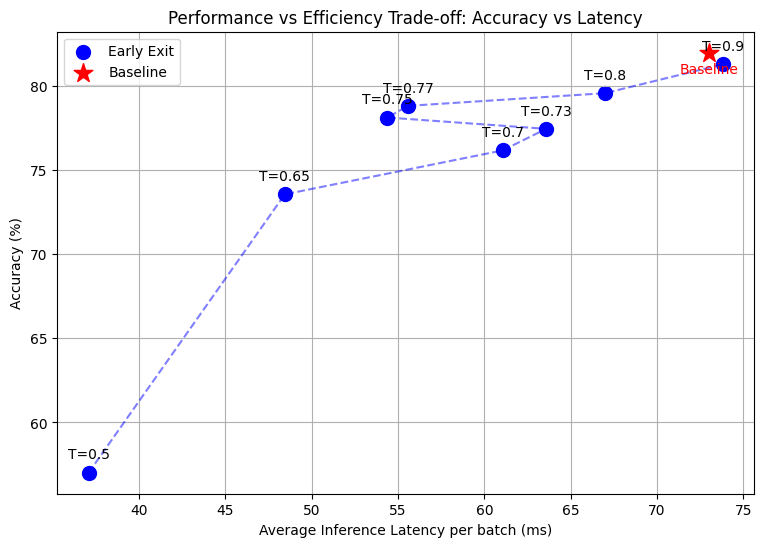

In [25]:
import matplotlib.pyplot as plt

thresholds = [0.5, 0.65, 0.7, 0.73, 0.75, 0.77, 0.8, 0.9]
accuracies = []
latencies = []
print("Evaluating different confidence thresholds...")
for t in thresholds:
    early_exit_bert.set_threshold(t) #TODO: Add finetuning
    print(f"\n--- Threshold: {t} ---")
    
    acc = eval_accuracy(early_exit_bert, test_dataloader, device=DEVICE)
    lat, _ = eval_speed(early_exit_bert, test_dataloader, device=DEVICE)
    accuracies.append(acc * 100)
    latencies.append(lat)

# Get baseline for comparison
print(f"\n--- Baseline Model ---")
base_acc = eval_accuracy(baseline_model, test_dataloader, device=DEVICE) * 100
base_lat, _ = eval_speed(baseline_model, test_dataloader, device=DEVICE)

# Simplified Plotting
plt.figure(figsize=(9, 6))

# Plot Early Exit points
plt.scatter(latencies, accuracies, color='b', s=100, label='Early Exit')
plt.plot(latencies, accuracies, 'b--', alpha=0.5)

for i, t in enumerate(thresholds):
    plt.annotate(f"T={t}", (latencies[i], accuracies[i]), 
                 textcoords="offset points", xytext=(0, 10), ha='center')

# Plot Baseline
plt.scatter([base_lat], [base_acc], color='r', marker='*', s=200, label='Baseline')
plt.annotate("Baseline", (base_lat, base_acc), 
             textcoords="offset points", xytext=(0, -15), ha='center', color='red')

plt.title('Performance vs Efficiency Trade-off: Accuracy vs Latency')
plt.xlabel('Average Inference Latency per batch (ms)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()